# QAOA Master Notebook

Welcome to the main Jupyter Notebook for the Quantum Approximate Optimization Algorithm (QAOA) implementation. 
We are building this up step-by-step.

---
## Day 1: Quantum Computing Fundamentals

Before we can write QAOA, we must master the basics of Qiskit, circuit construction, and the modern IBM Primitives.

## Day 7: QAOA Theory

### What is QAOA?
QAOA is a hybrid quantum-classical algorithm for optimization problems. It builds a parameterized quantum circuit and uses a classical optimizer to find good parameters.

### Cost Hamiltonian
- Encodes the optimization problem into quantum form.
- For QUBO problems, it represents the objective function we want to minimize.
- Lower energy means a better solution.

### Mixer Hamiltonian
- Helps the quantum state explore different bitstrings.
- Introduces transitions between basis states.
- Prevents the algorithm from staying trapped in one region of the search space.

### p-layer concept
- A QAOA circuit with **p layers** applies the cost and mixer operations p times.
- Each layer increases the expressiveness of the circuit.
- More layers can improve solution quality.

### Critical: Depth vs Noise Trade-off
- **Higher p** means a deeper circuit with more gates.
- **Real quantum hardware is noisy**: each gate adds the risk of error.
- The trade-off is:
  - Low p → less noise but less power
  - High p → more power but more noise

**Takeaway:** On real hardware, there is an optimal intermediate p where the circuit is powerful enough to improve solutions without being overwhelmed by noise.

### 0. Google Colab Setup
Since you are running this in Colab, your environment resets and doesn't have Qiskit installed by default. 
**Run the cell below once** to install the required libraries, then proceed!
*(Note: You might see a prompt to "Restart Session" afterwards. If so, restart the session and continue.)*

In [2]:
%%capture
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime pylatexenc matplotlib yfinance scipy

### 1. Setup & Imports
Let's import what we need from Qiskit.

In [3]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Primitives are the modern way to execute circuits in Qiskit v1.x
from qiskit.primitives import StatevectorSampler as Sampler

print("Imports successful. You are ready to go!")

Imports successful. You are ready to go!


### 2. Your First Quantum Circuit

In classical computing, a bit is either `0` or `1`. In quantum computing, we use a **qubit**, which defaults to being in the `|0>` state.

Let's create a circuit with 1 Qubit and 1 Classical Bit (to store our measurement result).

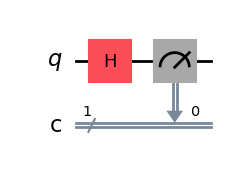

In [4]:
# Create a Quantum Circuit acting on 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# 1. Apply the Hadamard (H) gate to the qubit 0.
# The H gate puts the qubit into an equal superposition of |0> and |1>.
qc.h(0)

# 2. Measure the qubit (collapse the superposition) and store the result in classical bit 0.
qc.measure(0, 0)

# 3. Draw the circuit so we can see what we built.
qc.draw('mpl')

my version with 3 qubit

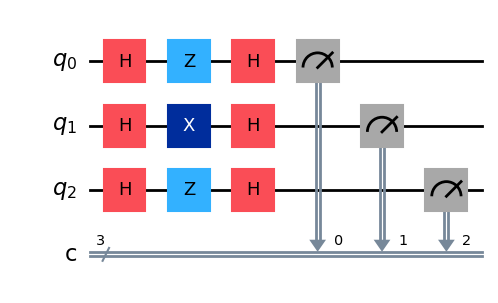

In [5]:
# Create a Quantum Circuit acting on 1 qubit and 1 classical bit
qc = QuantumCircuit(3, 3)

# 1. Apply the Hadamard (H) gate to the qubit 0.
# The H gate puts the qubit into an equal superposition of |0> and |1>.

qc.h([0,1,2])
qc.z([0,2])
qc.x(1)
qc.h([0,1,2])

# 2. Measure the qubit (collapse the superposition) and store the result in classical bit 0.
qc.measure(range(3),range(3))

# 3. Draw the circuit so we can see what we built.
qc.draw('mpl')
# qc.draw('text')

### 3. The Sampler Primitive

In older versions of Qiskit, you used `execute(circuit, backend)` to run jobs. Now, IBM provides **Primitives**.

The **Sampler** primitive samples from quantum circuits to estimate the probability distributions of the outputs.
- **When to use it:** When you need a distribution of bitstrings (e.g., getting "010", "101", etc.). This is exactly what we need for QAOA since we want to find the optimal stock subset string!

Let's run our superposition circuit through the local Sampler.

Counts: {'101': 1000}


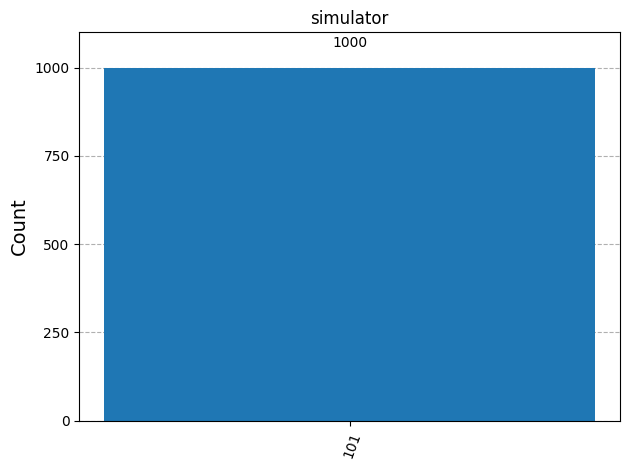

In [6]:
# Initialize the local Sampler (StatevectorSampler simulates it perfectly without noise)
sampler = Sampler()

# The Sampler uses a run() method. You must pass the circuit in a list [].
job = sampler.run([qc], shots=1000)

# Wait for the result
result = job.result()

# Extract the counts. In Qiskit 1.x, we get the result for the first circuit published via pub_result[0].
# We then access the data using the classical register name, which by default is 'c'.
pub_result = result[0]
counts = pub_result.data.c.get_counts()

print("Counts:", counts)
plot_histogram(counts,title="simulator")

In [7]:
import json
import os
import getpass
from qiskit_ibm_runtime import QiskitRuntimeService

# Try to find the local apikey.json
possible_paths = ["../apikey.json", "apikey.json"]
api_key_path = None

for path in possible_paths:
    if os.path.exists(path):
        api_key_path = path
        break

if api_key_path:
    with open(api_key_path, "r") as f:
        ibm_token = json.load(f).get("apikey")
else:
    ibm_token = getpass.getpass("Please paste your IBM Quantum API Token here: ")

# Authenticate and define the 'service' variable!
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=ibm_token, set_as_default=True, overwrite=True)

service = QiskitRuntimeService()
print("Successfully defined 'service' and authenticated!")


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-04-23 12:02:16,017: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Successfully defined 'service' and authenticated!


**Analysis:** Because we applied a Hadamard gate, you should see roughly a 50/50 split between measuring `0` and `1`. No single execution is predictable, but over 1000 shots, the statistics converge!

### 4. Setting up your IBM Quantum Account

**Colab Upload Note:** If you are running in Colab, you need to click the "Files" folder icon on the left sidebar and upload your `apikey.json` file there before running this cell!

---
## Day 8: QAOA in Qiskit — QUBO → Operator → QAOA Circuit

Now we connect everything! We will:
1. **Build our QUBO Q-matrix** (recap from Day 4)
2. **Convert it to a quantum operator** (Ising Hamiltonian)
3. **Build the actual QAOA circuit** and visualize it

### Why do we need a conversion?
- Our QUBO uses classical binary variables: $x_i \in \{0, 1\}$
- Quantum computers measure qubits in the Z-basis: eigenvalues $\{+1, -1\}$
- The bridge formula is: $x_i = \frac{1 - Z_i}{2}$
  - If qubit measures $+1$ (spin up) → $x_i = 0$ (skip stock)
  - If qubit measures $-1$ (spin down) → $x_i = 1$ (buy stock)

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
from itertools import product as iter_product

# New Qiskit imports for Day 8
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz

np.set_printoptions(suppress=True, precision=4)
# print("Day 8 imports ready!")

### Step 1: Build our QUBO Q-Matrix (recap from Day 4)
We fetch live stock data using `yfinance` so this works on any Colab/CPU without needing local files.
Using only 3 Bank Nifty stocks to keep the quantum circuit small and readable.

In [12]:
# ----- Fetch live stock data using yfinance -----
# Download each ticker separately to avoid MultiIndex and database lock issues
tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS','AXISBANK.NS']
n_qubits = len(tickers)

print(f"Downloading 10 year of data for {tickers}...")
close_prices = pd.DataFrame()
for t in tickers:
    df = yf.download(t, period='10y', auto_adjust=True, progress=False)
    close_prices[t] = df['Close']

# Drop any rows with missing data
close_prices = close_prices.dropna()

# Calculate daily returns
daily_returns = close_prices.pct_change(fill_method=None).dropna()

# Expected returns (annualized)
mu = daily_returns.mean().values * 252

# Covariance matrix (annualized)
sigma = daily_returns.cov().values * 252

print(f"\nStocks: {tickers}")
print(f"Expected annual returns: {np.round(mu, 4)}")
print(f"\nCovariance matrix:")
print(np.round(sigma, 4))


Stocks: ['HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'AXISBANK.NS']
Expected annual returns: [0.1422 0.2314 0.2367 0.1641]

Covariance matrix:
[[0.052  0.0348 0.0305 0.0342]
 [0.0348 0.088  0.0609 0.0628]
 [0.0305 0.0609 0.1036 0.0574]
 [0.0342 0.0628 0.0574 0.1036]]


In [13]:
# Same build_Q_matrix function from Day 4
def build_Q_matrix(returns, cov, penalty, k, risk_weight=1.0):
    n = len(returns)
    Q = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                Q[i][i] = -returns[i] + risk_weight * cov[i][i] + penalty * (1 - 2 * k)
            else:
                Q[i][j] = risk_weight * cov[i][j] + penalty
    return (Q + Q.T) / 2

k = 2              # pick exactly 2 stocks
penalty = 10.0     # heavy penalty for breaking the k-constraint
risk_weight = 0.5

Q = build_Q_matrix(mu, sigma, penalty=penalty, k=k, risk_weight=risk_weight)

print(f"QUBO Q-Matrix ({n_qubits}x{n_qubits}):")
print(np.round(Q, 4))

QUBO Q-Matrix (4x4):
[[-30.1162  10.0174  10.0152  10.0171]
 [ 10.0174 -30.1874  10.0305  10.0314]
 [ 10.0152  10.0305 -30.1849  10.0287]
 [ 10.0171  10.0314  10.0287 -30.1123]]


### Step 2: Convert QUBO → Ising Hamiltonian (Quantum Operator)

We substitute $x_i = \frac{1 - Z_i}{2}$ into our QUBO formula $f(x) = \sum Q_{ij} x_i x_j$.

After expanding, we get three types of terms:
1. **Constant offset** $c_0$ — just a number we add back at the end
2. **Single-Z terms** $c_i Z_i$ — single qubit rotations
3. **ZZ interaction terms** $c_{ij} Z_i Z_j$ — two-qubit entanglement gates

These get packed into Qiskit's `SparsePauliOp` format.

In [14]:
def qubo_to_ising(Q):
    """
    Convert a QUBO Q-matrix into an Ising Hamiltonian (SparsePauliOp).
    Returns the Hamiltonian operator and a constant offset.
    """
    n = len(Q)
    pauli_list = []
    offset = 0.0

    # --- Diagonal terms: Q_ii * x_i ---
    # x_i = (1 - Z_i)/2, so x_i^2 = x_i (binary!)
    # Q_ii * (1 - Z_i)/2 = Q_ii/2  -  Q_ii/2 * Z_i
    for i in range(n):
        offset += Q[i][i] / 2.0

        # Build Pauli string: e.g. for n=3, qubit i=1 -> "IZI"
        # NOTE: Qiskit orders strings RIGHT to LEFT (qubit 0 is rightmost)
        pauli_str = ['I'] * n
        pauli_str[n - 1 - i] = 'Z'
        pauli_list.append((''.join(pauli_str), -Q[i][i] / 2.0))

    # --- Off-diagonal terms: Q_ij * x_i * x_j (i < j) ---
    # x_i * x_j = ((1-Z_i)/2) * ((1-Z_j)/2) = 1/4 - Z_i/4 - Z_j/4 + Z_i*Z_j/4
    # We combine Q_ij + Q_ji since Q is symmetric
    for i in range(n):
        for j in range(i + 1, n):
            c = Q[i][j] + Q[j][i]  # combined coefficient

            offset += c / 4.0

            # Single Z_i contribution
            p_i = ['I'] * n
            p_i[n - 1 - i] = 'Z'
            pauli_list.append((''.join(p_i), -c / 4.0))

            # Single Z_j contribution
            p_j = ['I'] * n
            p_j[n - 1 - j] = 'Z'
            pauli_list.append((''.join(p_j), -c / 4.0))

            # Z_i Z_j interaction
            p_ij = ['I'] * n
            p_ij[n - 1 - i] = 'Z'
            p_ij[n - 1 - j] = 'Z'
            pauli_list.append((''.join(p_ij), c / 4.0))

    # SparsePauliOp groups duplicate Pauli strings and sums their coefficients
    hamiltonian = SparsePauliOp.from_list(pauli_list).simplify()

    # IMPORTANT: QAOAAnsatz requires REAL coefficients.
    # SparsePauliOp stores them as complex by default (even if imaginary part is 0).
    # We must explicitly cast to real, otherwise Qiskit throws:
    # "Operator contains complex coefficients, which are not supported."
    real_coeffs = hamiltonian.coeffs.real
    hamiltonian = SparsePauliOp(hamiltonian.paulis, coeffs=real_coeffs)

    return hamiltonian, offset


# Convert our Q matrix!
cost_hamiltonian, offset = qubo_to_ising(Q)

print("Ising Hamiltonian (quantum operator) created!")
print(f"Constant offset: {offset:.4f}")
print(f"\nOperator terms (Z = single qubit, ZZ = entanglement):")
print(cost_hamiltonian)

Ising Hamiltonian (quantum operator) created!
Constant offset: -30.2302

Operator terms (Z = single qubit, ZZ = entanglement):
SparsePauliOp(['IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[0.0332+0.j, 0.0541+0.j, 0.0552+0.j, 0.0175+0.j, 5.0087+0.j, 5.0076+0.j,
 5.0086+0.j, 5.0152+0.j, 5.0157+0.j, 5.0144+0.j])


### Quick Sanity Check
Let's verify our conversion is correct by comparing QUBO and Ising values for all 8 possible bitstrings of 3 stocks.

In [15]:
print(f"{'Bitstring':<12} {'QUBO Value':<14} {'Ising+Offset':<14} {'Match?'}")
print("-" * 50)

for bits in iter_product([0, 1], repeat=n_qubits):
    x = np.array(bits, dtype=int)

    # Classical QUBO value
    qubo_val = float(x @ Q @ x)

    # Convert x -> z:  z_i = 1 - 2*x_i
    z = 1 - 2 * x

    # Evaluate Ising Hamiltonian manually
    ising_val = 0.0
    for pauli_term, coeff in zip(cost_hamiltonian.paulis, cost_hamiltonian.coeffs):
        term_val = 1.0
        label = str(pauli_term)
        for q_idx, ch in enumerate(reversed(label)):
            if ch == 'Z':
                term_val *= z[q_idx]
        ising_val += float(coeff.real) * term_val
    ising_val += offset

    match = abs(qubo_val - ising_val) < 1e-6
    selected = [tickers[i] for i in range(n_qubits) if x[i] == 1]
    print(f"{str(x):<12} {qubo_val:<14.4f} {ising_val:<14.4f} {'YES' if match else 'NO'}  {selected}")

Bitstring    QUBO Value     Ising+Offset   Match?
--------------------------------------------------
[0 0 0 0]    0.0000         0.0000         YES  []
[0 0 0 1]    -30.1123       -30.1123       YES  ['AXISBANK.NS']
[0 0 1 0]    -30.1849       -30.1849       YES  ['SBIN.NS']
[0 0 1 1]    -40.2398       -40.2398       YES  ['SBIN.NS', 'AXISBANK.NS']
[0 1 0 0]    -30.1874       -30.1874       YES  ['ICICIBANK.NS']
[0 1 0 1]    -40.2370       -40.2370       YES  ['ICICIBANK.NS', 'AXISBANK.NS']
[0 1 1 0]    -40.3113       -40.3113       YES  ['ICICIBANK.NS', 'SBIN.NS']
[0 1 1 1]    -30.3034       -30.3034       YES  ['ICICIBANK.NS', 'SBIN.NS', 'AXISBANK.NS']
[1 0 0 0]    -30.1162       -30.1162       YES  ['HDFCBANK.NS']
[1 0 0 1]    -40.1943       -40.1943       YES  ['HDFCBANK.NS', 'AXISBANK.NS']
[1 0 1 0]    -40.2705       -40.2705       YES  ['HDFCBANK.NS', 'SBIN.NS']
[1 0 1 1]    -30.2912       -30.2912       YES  ['HDFCBANK.NS', 'SBIN.NS', 'AXISBANK.NS']
[1 1 0 0]    -40.2688       -

### Step 3: Build the QAOA Circuit

Now that we have our Hamiltonian operator, we can build the QAOA circuit!

Reminder of how QAOA works:
1. **Start**: Put all qubits in superposition (Hadamard gates)
2. **Cost layer** ($e^{-i\gamma H_C}$): Rotates qubits based on our portfolio problem
3. **Mixer layer** ($e^{-i\beta H_M}$): X-rotations to explore new combinations
4. Repeat steps 2-3 for $p$ layers

Qiskit's `QAOAAnsatz` builds this entire circuit automatically from our Hamiltonian!

QAOA Circuit created with p=1 layer(s)
Number of qubits: 4
Number of parameters to optimize: 2
  - 1 gamma(s) for the cost layer
  - 1 beta(s) for the mixer layer

Parameter names: ['β[0]', 'γ[0]']

--- High-level QAOA circuit ---


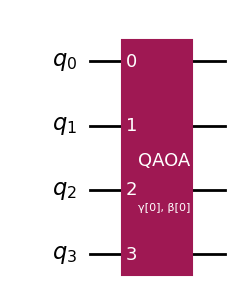

In [16]:
# Build QAOA circuit with p=1 layer (simplest version)
p = 1
qaoa_circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=p)

print(f"QAOA Circuit created with p={p} layer(s)")
print(f"Number of qubits: {qaoa_circuit.num_qubits}")
print(f"Number of parameters to optimize: {qaoa_circuit.num_parameters}")
print(f"  - {p} gamma(s) for the cost layer")
print(f"  - {p} beta(s) for the mixer layer")
print(f"\nParameter names: {[p.name for p in qaoa_circuit.parameters]}")

# Draw the high-level circuit
print("\n--- High-level QAOA circuit ---")
qaoa_circuit.draw('mpl', style='iqp')

--- Decomposed QAOA circuit (actual gates) ---


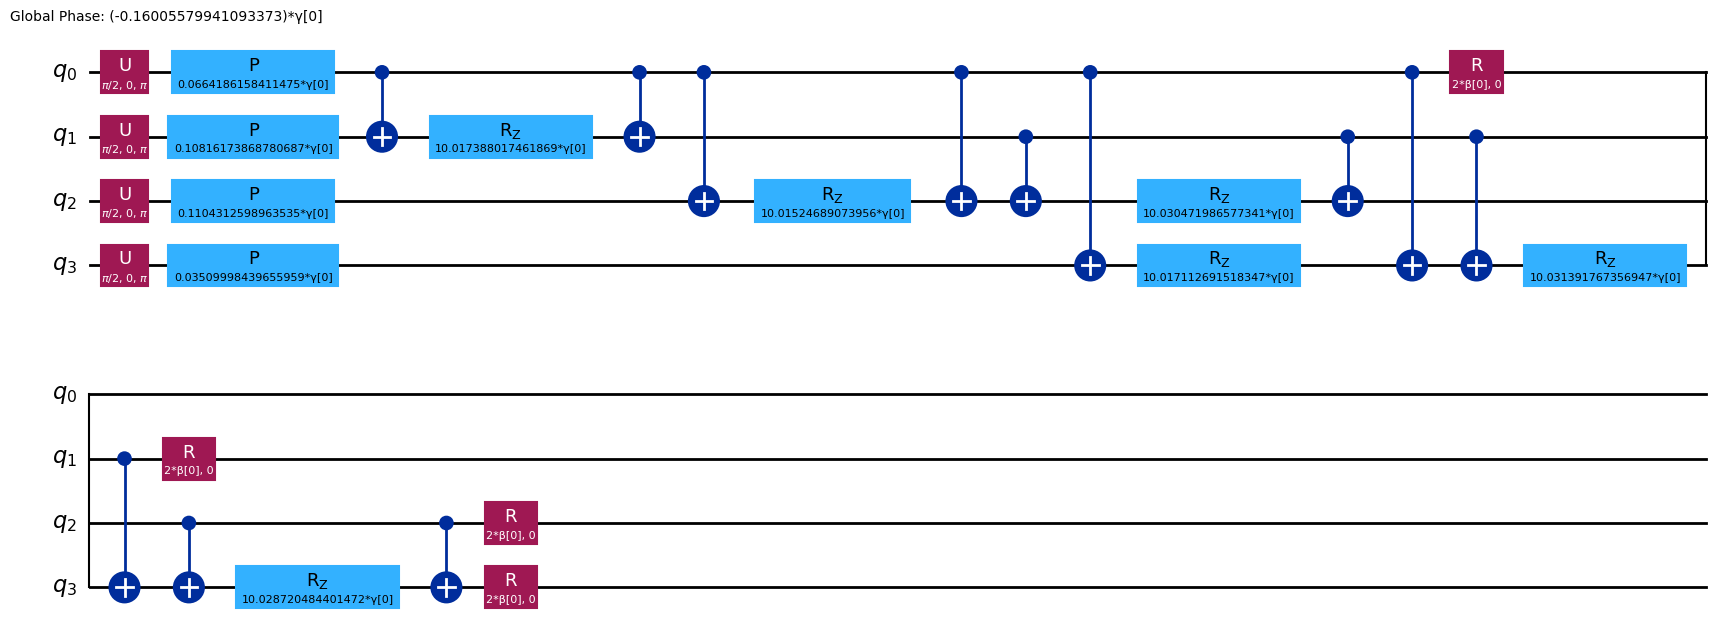

In [17]:
# Now let's decompose it to see the actual quantum gates inside!
# You'll see:
#   - H gates at the start (superposition)
#   - Rzz gates (two-qubit interactions from ZZ terms)
#   - Rz gates (single-qubit rotations from Z terms)
#   - Rx gates (mixer layer)

print("--- Decomposed QAOA circuit (actual gates) ---")
qaoa_circuit.decompose(reps=3).draw('mpl', style='iqp')

---
## Day 9: Run Simulation (The Optimization Loop)

We have our `QAOAAnsatz` circuit, but right now its parameters ($\gamma$ and $\beta$) are just empty algebraic placeholders. 

Here we do the actual **hybrid quantum-classical algorithm**:
1. Pick a classical optimizer (`COBYLA`).
2. The optimizer picks random starting values for $\gamma$ and $\beta$.
3. We run the circuit through the **Estimator** primitive to calculate the "Energy" of the Hamiltonian.
4. The optimizer adjusts $\gamma$ and $\beta$ and repeats Step 3 over and over until it finds the absolute lowest Energy.
5. We use those final optimal parameters to run the circuit one last time in the **Sampler** primitive to extract our winning portfolio bitstrings!

In [18]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

# 1. Initialize the Estimator (used to calculate energy fast on a simulator)
estimator = StatevectorEstimator()

# 2. Define the objective function that the classical optimizer will try to MINIMIZE
def evaluate_expectation(x):
    # x is an array of [gamma, beta] values from the optimizer
    
    # The Estimator needs a "Pub" (circuit, observable, parameter_values)
    pub = (qaoa_circuit, cost_hamiltonian, x)
    
    # Run it and extract the expected value (Energy)
    job = estimator.run([pub])
    result = job.result()[0]
    
    # Return the energy. Lower is better!
    return result.data.evs

# 3. Give the optimizer a random starting point for [gamma, beta]
initial_point = np.array([0.5, 0.5])

print("Starting COBYLA optimization loop... (this might take a few seconds)")
res = minimize(evaluate_expectation, initial_point, method='COBYLA')

optimal_params = res.x
optimal_energy = res.fun

print("\n✅ Optimization Complete!")
print(f"Lowest Energy Found (Ising offset excluded here): {optimal_energy:.4f}")
print(f"Optimal Parameters:\n  gamma = {optimal_params[0]:.4f}\n  beta  = {optimal_params[1]:.4f}")

Starting COBYLA optimization loop... (this might take a few seconds)


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



✅ Optimization Complete!
Lowest Energy Found (Ising offset excluded here): -6.8863
Optimal Parameters:
  gamma = 1.2914
  beta  = 1.5175


### Extracting the Winning Bitstrings

Now that the classical optimizer discovered that `gamma=...` and `beta=...` yields the lowest energy, let's plug those numbers directly into the circuit.
Then, we take a "picture" of the quantum state using the **Sampler** to get a histogram of probabilities!

Top 5 Most Probable Portfolios found by QAOA:
--------------------------------------------------
Bitstring 0101 | QUBO Value: -40.2370 | Prob:  13.7% | ['ICICIBANK.NS', 'AXISBANK.NS']
Bitstring 0011 | QUBO Value: -40.2398 | Prob:  12.8% | ['SBIN.NS', 'AXISBANK.NS']
Bitstring 0110 | QUBO Value: -40.3113 | Prob:  12.3% | ['ICICIBANK.NS', 'SBIN.NS']
Bitstring 1010 | QUBO Value: -40.2705 | Prob:  12.1% | ['HDFCBANK.NS', 'SBIN.NS']
Bitstring 1001 | QUBO Value: -40.1943 | Prob:  11.7% | ['HDFCBANK.NS', 'AXISBANK.NS']


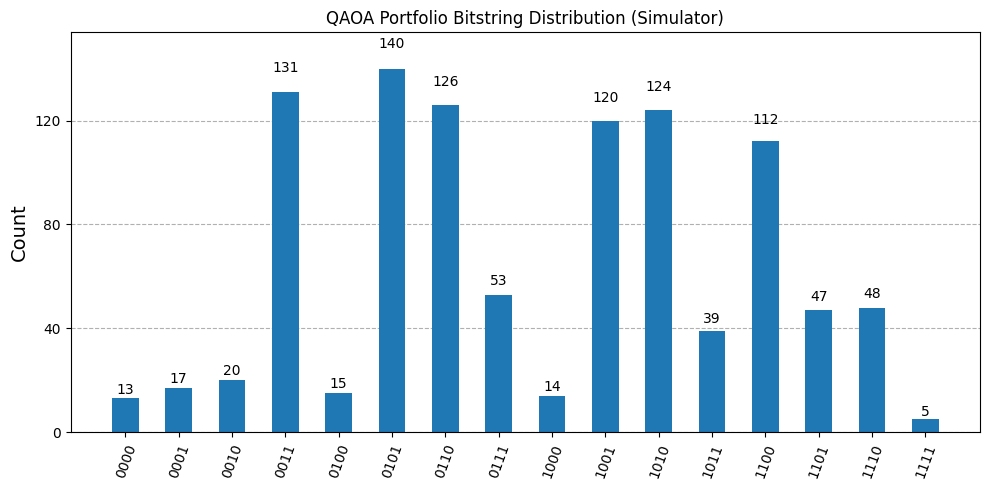

In [19]:
from qiskit.primitives import StatevectorSampler

# 1. Bind the winning parameters to the circuit
optimized_circuit = qaoa_circuit.assign_parameters(optimal_params)

# 2. Add measurement operations to every qubit so we can actually read the results
optimized_circuit.measure_all()

# 3. Run it through the Sampler to generate statistics
sampler = StatevectorSampler()
job = sampler.run([optimized_circuit])
result = job.result()[0]

# 4. Extract the counts from the measurement register (meas)
raw_counts = result.data.meas.get_counts()

# IMPORTANT FIX: Qiskit Endianness
# Qiskit returns bitstrings with Qubit 0 as the RIGHTMOST digit.
# E.g., '110' means Qubit 2 = 1, Qubit 1 = 1, Qubit 0 = 0.
# We reverse ALL the keys here first so that reading left-to-right means Q0, Q1, Q2!
counts = {k[::-1]: v for k, v in raw_counts.items()}

# Calculate total shots dynamically to fix the percentage calculation
total_shots = sum(counts.values())

# Sort them from most probable to least probable
sorted_counts = {k: v for k, v in sorted(counts.items(), key=lambda item: item[1], reverse=True)}

print("Top 5 Most Probable Portfolios found by QAOA:")
print("-" * 50)
top_5 = list(sorted_counts.items())[:5]
for bitstring, count in top_5:
    # Because we reversed the keys above, the string reads naturally: index 0 = stock 0
    x = np.array(list(bitstring), dtype=int)
    selected_stocks = [tickers[i] for i in range(n_qubits) if x[i] == 1]
    
    # Calculate exact classical QUBO value for validation
    qubo_val = float(x @ Q @ x)
    
    print(f"Bitstring {bitstring} | QUBO Value: {qubo_val:>8.4f} | Prob: {count/total_shots:>6.1%} | {selected_stocks}")

# Plot it!
plot_histogram(counts, title="QAOA Portfolio Bitstring Distribution (Simulator)", figsize=(10,5))

---
## Day 10: Run on Real IBM Hardware

We just proved that running our customized QAOA circuit () on an ideal mathematical simulator perfectly finds the optimal 2-stock portfolio.

Now, it's time for the true physical test. We are going to send this exact same circuit to a real macroscopic quantum computer residing in an IBM data center somewhere in the world.

> ⚠️ **EXPECTATION WARNING:** A  QAOA circuit with 3 stocks requires dozens of entangling CNOT gates. On current 'noisy intermediate-scale quantum' (NISQ) free-tier hardware, this many gates usually results in total decoherence. We fully expect the hardware output to look like random noise compared to our beautiful simulator output. We are running this to *prove* the current noise limits!

In [20]:
from qiskit_ibm_runtime import SamplerV2 as RealSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Find the least busy real quantum computer
# (Assuming you already authenticated and created 'service' in Step 4 at the top of the notebook)
print("Looking for the least busy quantum computer...")
backend = service.least_busy(simulator=False, operational=True)
print(f"✅ Selected Backend: {backend.name}")

# 2. Transpile the circuit for this specific hardware
# Real hardware has specific physical wiring layouts. The transpiler rewrites our logical circuit
# into physical machine instructions that this specific backend understands.
pass_manager = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuit = pass_manager.run(optimized_circuit)

# 3. Initialize the real Sampler using our selected backend
real_sampler = RealSampler(mode=backend)

# 4. Submit the job!
print(f"🚀 Submitting job to {backend.name}...")
job = real_sampler.run([isa_circuit], shots=1000)

print(f"Job successfully submitted!")
print(f"Job ID: {job.job_id()}")
print("Dashboard: https://quantum.ibm.com/jobs")

print("\nWaiting in queue for hardware execution... (This could take minutes or hours depending on the public queue!)")
result = job.result()
print("✅ Hardware Execution Complete!")

Looking for the least busy quantum computer...


qiskit_runtime_service.backends:WARNING:2026-04-23 12:04:00,325: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-23 12:04:01,448: Using instance: open-instance, plan: open


✅ Selected Backend: ibm_fez
🚀 Submitting job to ibm_fez...
Job successfully submitted!
Job ID: d7l0lcokj84c73ceefpg
Dashboard: https://quantum.ibm.com/jobs

Waiting in queue for hardware execution... (This could take minutes or hours depending on the public queue!)
✅ Hardware Execution Complete!


### Extracting and Plotting the Real Hardware Results
Let's see if the quantum hardware survived the circuit depth, or if it degraded into static noise.

Top 5 Bitstrings from REAL IBM Hardware:
--------------------------------------------------
Bitstring 0110 | QUBO Value: -40.3113 | Prob:  13.3% | ['ICICIBANK.NS', 'SBIN.NS']
Bitstring 1100 | QUBO Value: -40.2688 | Prob:  13.0% | ['HDFCBANK.NS', 'ICICIBANK.NS']
Bitstring 1001 | QUBO Value: -40.1943 | Prob:  11.8% | ['HDFCBANK.NS', 'AXISBANK.NS']
Bitstring 1010 | QUBO Value: -40.2705 | Prob:  11.1% | ['HDFCBANK.NS', 'SBIN.NS']
Bitstring 0011 | QUBO Value: -40.2398 | Prob:  11.0% | ['SBIN.NS', 'AXISBANK.NS']


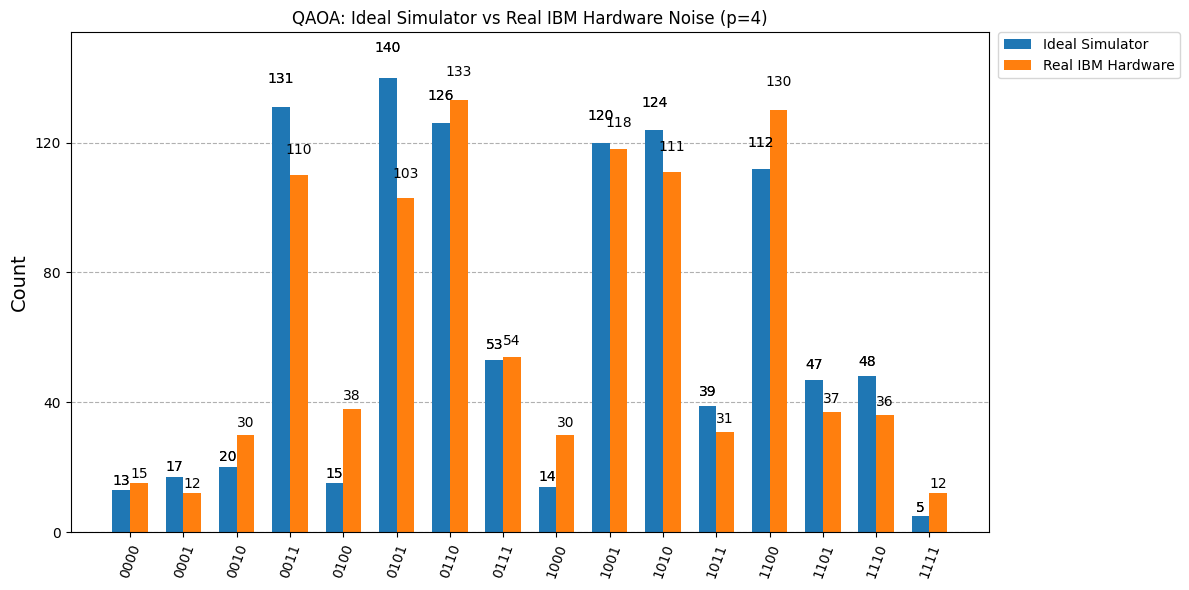

In [21]:
# Extract the result
pub_result = result[0]

# Get raw counts from the measurement register
real_raw_counts = pub_result.data.meas.get_counts()

# Fix Qiskit Endianness (just like we did for the simulator)
real_counts = {k[::-1]: v for k, v in real_raw_counts.items()}
total_real_shots = sum(real_counts.values())

sorted_real = {k: v for k, v in sorted(real_counts.items(), key=lambda item: item[1], reverse=True)}

print("Top 5 Bitstrings from REAL IBM Hardware:")
print("-" * 50)
for bitstring, count in list(sorted_real.items())[:5]:
    x = np.array(list(bitstring), dtype=int)
    selected_stocks = [tickers[i] for i in range(n_qubits) if x[i] == 1]
    qubo_val = float(x @ Q @ x)
    print(f"Bitstring {bitstring} | QUBO Value: {qubo_val:>8.4f} | Prob: {count/total_real_shots:>6.1%} | {selected_stocks}")

# Plot Side-by-Side Comparison
import matplotlib.pyplot as plt

# We already have 'counts' from the Day 9 Simulator
simulator_counts = counts

# Standardize keys so both dictionaries have all 8 bitstrings
all_keys = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
sim_plot = {k: simulator_counts.get(k, 0) for k in all_keys}
real_plot = {k: real_counts.get(k, 0) for k in all_keys}

plot_histogram([sim_plot, real_plot], 
               title="QAOA: Ideal Simulator vs Real IBM Hardware Noise (p=4)",
               legend=['Ideal Simulator', 'Real IBM Hardware'],
               figsize=(12, 6))